## Imports and functions

In [1]:
import numpy as np
from numpy.fft import fftshift, fft, ifft, rfft, irfft, fftfreq
from numpy.typing import NDArray
import json
from pathlib import Path
from scipy.constants import speed_of_light as C_MKS
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 273+98:
        logp = 133.42927 - 9302.868 / temp_K + \
            0.03114431 * temp_K - 49.37679 * np.log10(temp_K)
    else:
        logp = 10.86423 - 5619.406 / temp_K + 0.00000345 * \
            temp_K - 1.04111  * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)


def load_avg_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads and averages all data files under the pug directory.

    Args:
        path (Path): Path to the directory containing the .bin files, typ. 
        'Channel1'.

    Returns:
        NDArray[np.complex128]: Averaged and carrier-offset interferogram.
    """
    data_files = path.glob('*.bin')
    data_list = []
    for fname in data_files:
        data_list.append(load_pug_bin(fname))

    # Handle different lengths by padding with NaN
    max_len = max(len(d) for d in data_list)
    matrix = np.full((max_len, len(data_list)), np.nan, dtype=complex)

    for i, d in enumerate(data_list):
        matrix[:len(d), i] = d

    # Compute average across files (ignoring NaNs for uneven lengths)
    avg_signal = np.nanmean(matrix, axis=1)
    return avg_signal

def load_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads a single .bin file in the method used by the PUG.

    Args:
        path (Path): Path to the .bin file.

    Returns:
        NDArray[np.complex128]: Carrier-subtracted interferogram.
    """
    # Load raw binary floats (32-bit)
    numbers = np.fromfile(path, dtype=np.float32)

    # Convert to complex: (real, imag) pairs
    complex_data = numbers[0::2] + 1j * numbers[1::2]
    return complex_data

def load_json(path: Path) -> dict:
    """
    Loads a .json file as a dictionary.

    Args:
        path (Path): Path to .json file.

    Returns:
        dict: Contents of the file.
    """
    with open(path, 'r') as f:
        return json.load(f)                                                        

def load_pug(path) -> tuple[dict, NDArray] | tuple[None, None]:
    """
    Opens a dialog to ask the user for the PUG's data directory. Loads data exported from the PUG.

    Returns:
        tuple[dict, NDArray]|tuple[None,None]: A parameter dictionary and a complex,
        averaged data array. Returns None for both if the dialog is canceled.
    """
    apriori = load_json(path / 'apriori_params.json')
    computed =load_json(path / 'computed_params.json')
    gage = load_json(path / 'gageCard_params.json')
    avg_data = load_avg_pug_bin(path / 'Output_data/Channel1')
    params = {}
    params.update(apriori)
    params.update(computed)
    params.update(gage)
    return params, avg_data

def calc_absorbance(spectrum):
    """
    Calculates the absorbance of the spectrum and updates internal variables.
    """

    return - np.log(spectrum) 

def calc_cepstral_modified_igm(absorbance, optical_axis, time_axis, freq_cuton: float, freq_cutoff: float): 
    """
    Calculates the modified igm based on the absorbance and updates internal values for
    it and the associated time and frequency axes.

    Args:
        freq_cuton (flaot): Start of the absorbance window 
        freq_cutoff (float): End of the absorbance window
    """
    # Cut axis and absorbance based on window bounds
    mask = (optical_axis >= freq_cuton) & (optical_axis <= freq_cutoff)
    cepstral_optical_axis = optical_axis[mask]
    absorbance_cut = absorbance[mask]

    # Calculate modified igm
    # mod_igm = irfft(absorbance_cut)
    mod_igm = ifft(absorbance_cut)

    # Calculate time axis
    cep_time_axis = np.linspace(
        time_axis[0], time_axis[-1], len(mod_igm))

    # Update internal variables
    cepstral_time_axis = cep_time_axis
    mod_igm = mod_igm
    return mod_igm, cepstral_optical_axis, cepstral_time_axis

def calc_cepstral_spectrum(mod_igm, cep_time_axis, time_cutons: float, time_cutoffs:float, filter='step'):
    """
    Calculates the background-subtracted spectrum and updates internal variables.

    Args:
        time_cutons (float): Start of 
        time_cutoffs (float): _description_
        filter (str, optional): _description_. Defaults to 'step'.

    Raises:
        ValueError: _description_
    """        
    if not isinstance(time_cutons, (list, tuple)):
        cutons = [time_cutons]
    else:
        cutons = time_cutons

    if not isinstance(time_cutoffs, (list, tuple)):
        cutoffs = [time_cutoffs]
    else:
        cutoffs = time_cutoffs


    for cuton, cutoff in zip(cutons, cutoffs):
        if filter == 'step':
            mask = (cep_time_axis >= cuton) & (cep_time_axis <= cutoff)
            mod_igm[mask] = 0
        else:
            raise ValueError(
                f'\"{filter}\" is not a valid input for argument filter')

    # cepstral_absorbance = -rfft(mod_igm)
    cepstral_absorbance = -fft(mod_igm)
    return np.abs(np.exp(cepstral_absorbance))  

def alias_frequency(f0, df, fs):
    """
    Compute the aliased frequency of a signal after shifting.

    Parameters:
        f0 : float
            Initial frequency (Hz)
        df : float
            Frequency shift applied before sampling (Hz)
        fs : float
            Sampling rate (Hz)

    Returns:
        float: Aliased frequency (Hz), in range [-fs/2, fs/2)
    """
    f = f0 + df
    return ((f + fs/2) % fs) - fs/2


## Data and Parameters (Steck)

In [ ]:
# Experimental parameters
temp_K = 273+156
B_field_gauss = .5
# B_field_gauss =0 
cell_length = .075

mass = au * 22.9897692807

nuc_spin_degen = 8

nu0_D1 = 508.3324657e12 
nu0_D2 = 508.8487162e12

Gamma_D1 = 2 * np.pi * 9.765e6
Gamma_D2 = 2 * np.pi * 9.795e6

lam_D1 = 589.7566617e-9
lam_D2 = 589.1583264e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# line info dict


lines = {'D1': {}, 'D2': {}}

lines['D1']['Fg2Fe1'] = {'center': nu0_D1 - 0.6643597983e9 -118.05e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['Fg2Fe2'] = {'center': nu0_D1 - 0.6643597983e9 + 70.83e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['Fg1Fe1'] = {'center': nu0_D1 + 1.1072663305e9  -118.05e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['Fg1Fe2'] = {'center': nu0_D1  + 1.1072663305e9 + 70.83e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['Fg2Fe1'] = {'center': nu0_D2 - 0.6643597983e9 -50.288e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['Fg2Fe2'] = {'center': nu0_D2 - 0.6643597983e9 -15.944e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg2Fe3'] = {'center': nu0_D2 - 0.6643597983e9 + 42.382e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['Fg1Fe0'] = {'center': nu0_D2 + 1.1072663305e9-66.097e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['Fg1Fe1'] = {'center': nu0_D2 + 1.1072663305e9-50.288e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['Fg1Fe2'] = {'center': nu0_D2 + 1.1072663305e9-15.944e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, transitions in lines.items():
    for transition, props in transitions.items():
        if line == 'D2':
            props['sigma'] = dop_sigmav_85 * nu0_D2 / c
            props['gamma'] = Gamma_D2/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
        elif line == 'D1':
            props['sigma'] = dop_sigmav_85 * nu0_D1 / c
            props['gamma'] = Gamma_D1/2
            props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                number_density(
                    temp_K) / (nuc_spin_degen * hbar * e0 * dop_sigmav_85)
            # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                # number_density(
                    # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)


## Cepstral 

In [58]:
path = Path(r"C:\Users\mike\Documents\School\Research\Diddams\data\20251124_14h13m25s")
exp_params, avg_signal = load_pug(path)

1934050
3021954
11000133.172353767
11000033.495000005
3.0
508000000000000.0 509750000000000.0


C:\Users\mike\AppData\Local\Temp\ipykernel_30588\3910819232.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


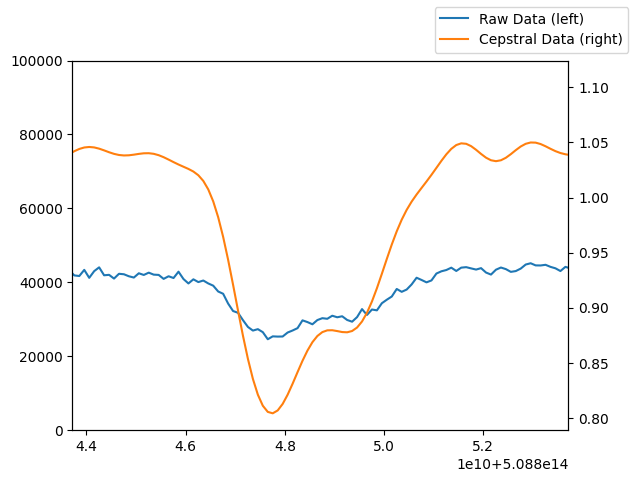

In [ ]:
fb1 = -36e6
fb2 = 27e6
f01 = -38e6
f02 = -39e6
fr1 = exp_params['fr_approx_Hz']
dfr = exp_params['dfr']
sample_rate = exp_params['sampling_rate_Hz']
nu_cw = C_MKS / exp_params['reference1_laser_wvl_nm'] * 1e9
cw_mode1 = round((nu_cw + fb1 - f01) / fr1)
print(cw_mode1)
harmonic = exp_params['nb_harmonic']
extra_ref_slope_factor = exp_params['extra_ref_slope_factor']

ppigm = len(avg_signal)
print(ppigm)

electrical_freq_cw_tooth_true = alias_frequency((fb1 - fb2)*harmonic, 0, fr1 + dfr)
print(electrical_freq_cw_tooth_true)
electrical_freq_cw_tooth_sampled = alias_frequency((fb1 - fb2+ extra_ref_slope_factor * sample_rate / 2/ np.pi)*harmonic, 0, sample_rate)
print(electrical_freq_cw_tooth_sampled)
ntooth_shift =  np.round(np.abs(electrical_freq_cw_tooth_sampled - electrical_freq_cw_tooth_true)/dfr) 
print(ntooth_shift)

axis_norm = fftshift(fftfreq(ppigm))
axis_N = axis_norm * ppigm
axis_shift = harmonic * ((cw_mode1) * fr1 + f01) + ntooth_shift * fr1 
# Still need to derive extra mode offset
raw_optical_axis = (axis_N ) * fr1 + axis_shift

raw_spectrum = np.flip(np.abs(fftshift(fft(avg_signal))))

absorbance = calc_absorbance(raw_spectrum)

time_axis = np.linspace(0, 1/ sample_rate, ppigm)
freq_cuton, freq_cutoff = (508e12, 509.75e12)
print(freq_cuton,freq_cutoff)
mod_igm, cepstral_optical, cepstral_time = calc_cepstral_modified_igm(absorbance, raw_optical_axis, time_axis, freq_cuton, freq_cutoff)

time_cutons, time_cutoffs = ([0, 845e-12], [31.2e-12 ,1/sample_rate + 1])
cepstral_spectrum_full = calc_cepstral_spectrum(np.copy(mod_igm), cepstral_time, time_cutons, time_cutoffs)
# Plot comparison
f, ax = plt.subplots()
ax2 = plt.twinx()
ax.plot(raw_optical_axis, raw_spectrum, color='tab:blue', label="Raw Data (left)")
# ax2.plot(peak_axis, unshift_spectrum, 'r-', label='Model (right)')
ax2.plot(cepstral_optical, cepstral_spectrum_full, color='tab:orange', label='Cepstral Data (right)')
ax.set_xlim(nu0_D2 - 5e9, nu0_D2 + 5e9)
# ax.set_xlim(nu0_D1 - 5e9, nu0_D1 + 5e9)
ax.set_ylim(0, 1e5)
f.legend()
f.show()


## Fit D2s

[[Model]]
    ((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg2Fe2')) * Model(transmission_model, prefix='v_Fg2Fe3')) * Model(transmission_model, prefix='v_Fg1Fe0')) * Model(transmission_model, prefix='v_Fg1Fe1')) * Model(transmission_model, prefix='v_Fg1Fe2'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 60
    # data points      = 100
    # variables        = 3
    chi-square         = 0.00233464
    reduced chi-square = 2.4068e-05
    Akaike info crit   = -1060.50679
    Bayesian info crit = -1052.69127
    R-squared          = 0.99646694
[[Variables]]
    bkg_c:               1.04272784 +/- 6.3701e-04 (0.06%) (init = 1)
    xoffset:            -3.2558e+08 +/- 6586606.85 (2.02%) (init = 0)
    amp_scale:           3589131.02 +/- 22676.6455 (0.63%) (init = 1e+09)
    v_Fg2Fe1center:      5.0885e+14 +/- 6576141.56 (0.00%) == 'v_Fg2Fe1center_rel + xoffset'
    v_Fg2Fe1amplitude:

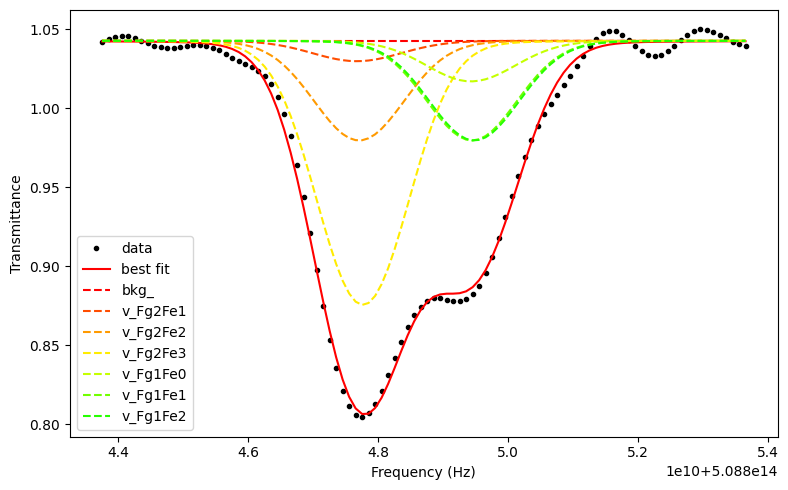

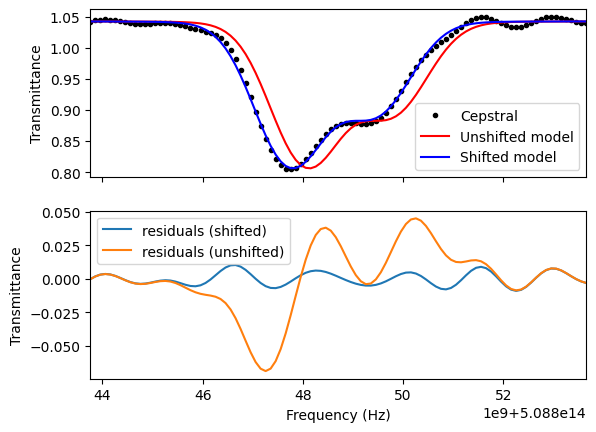

In [60]:
# D2 Fits ######################################3

mask = (cepstral_optical >= nu0_D2 - 5e9) & (cepstral_optical <= nu0_D2 + 5e9)
cepstral_axis = cepstral_optical[mask] 
cepstral_spectrum = cepstral_spectrum_full.copy()
cepstral_spectrum = cepstral_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)
# params.add('Rb87_ratio', value=ratio_87, max=ratio_87+.1, min=ratio_87-.1)

for transition, props in lines['D2'].items():
    prefix = f'v_{transition}'
    m = Model(transmission_model, prefix=prefix)
    model *= m
    params.update(m.make_params())

    # Give reasonable starting guesses
    params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
    params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
    # params[f'{prefix}sigma'].set(value=props['sigma'], min=.9 * props['sigma'], max=1.1 * props['sigma'])
    params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
    params.add(f'{prefix}center_rel', value=props['center'], vary=False)
    params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
    params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(cepstral_spectrum, params, x=cepstral_axis)

shifted_model = result.best_fit
# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(cepstral_axis, cepstral_spectrum, 'k.', label='data')
plt.plot(cepstral_axis, shifted_model, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=cepstral_axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(cepstral_axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(cepstral_axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Transmittance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
# model_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
model_axis = cepstral_axis
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshifted_model = result.eval(x=model_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshifted_model)
peaks_freq = np.array([model_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
f, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(cepstral_axis, cepstral_spectrum, 'k.', label='Cepstral')
axs[0].plot(model_axis, unshifted_model, 'r-', label='Unshifted model')
axs[0].plot(model_axis, shifted_model, 'b-', label='Shifted model')
axs[1].plot(cepstral_axis, cepstral_spectrum- shifted_model, label = 'residuals (shifted)')
axs[1].plot(cepstral_axis, cepstral_spectrum- unshifted_model, label = 'residuals (unshifted)')
# plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
axs[1].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Transmittance')
axs[1].set_ylabel('Transmittance')
axs[0].set_xlim(min(model_axis), max(model_axis))
axs[0].legend()
axs[1].legend()
plt.show()


## Fit D1s

[[Model]]
    ((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg2Fe1')) * Model(transmission_model, prefix='v_Fg2Fe2')) * Model(transmission_model, prefix='v_Fg1Fe1')) * Model(transmission_model, prefix='v_Fg1Fe2'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 46
    # data points      = 100
    # variables        = 3
    chi-square         = 0.00125300
    reduced chi-square = 1.2917e-05
    Akaike info crit   = -1122.73875
    Bayesian info crit = -1114.92324
    R-squared          = 0.99285446
[[Variables]]
    bkg_c:               1.02051167 +/- 4.6951e-04 (0.05%) (init = 1)
    xoffset:             4.1133e+08 +/- 8991466.67 (2.19%) (init = 0)
    amp_scale:           3693369.33 +/- 32430.2973 (0.88%) (init = 1e+09)
    v_Fg2Fe1center:      5.0833e+14 +/- 8985095.10 (0.00%) == 'v_Fg2Fe1center_rel + xoffset'
    v_Fg2Fe1amplitude:   1.1167e+08 +/- 980509.770 (0.88%) == 'v_Fg2Fe1amp_rel * amp_scale'
    v_Fg2Fe1sigma:       6.6

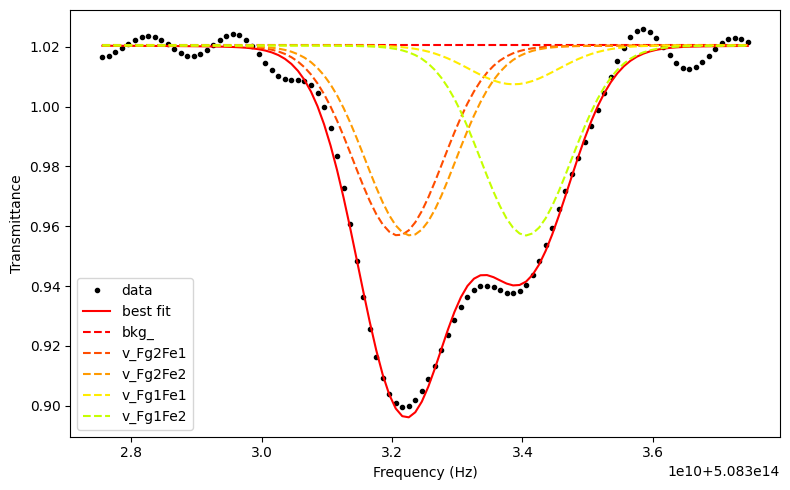

[5.08331856e+14 5.08333456e+14]
[0.89621669 0.94020601]


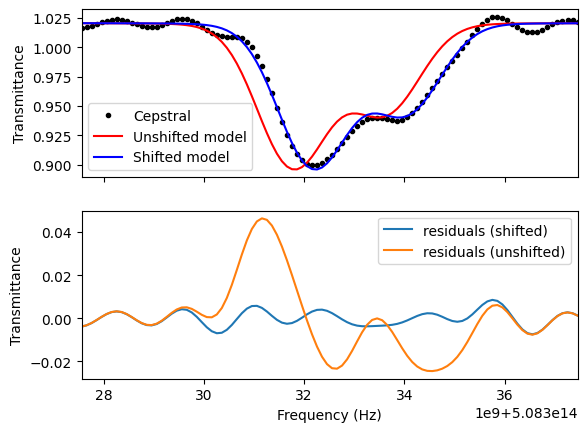

In [61]:
mask = (cepstral_optical>= nu0_D1 - 5e9) & (cepstral_optical<= nu0_D1 + 5e9) 
cepstral_axis = cepstral_optical[mask]
cepstral_spectrum = cepstral_spectrum_full.copy()
cepstral_spectrum = cepstral_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for transition, props in lines['D1'].items():
    prefix = f'v_{transition}'
    m = Model(transmission_model, prefix=prefix)
    model *= m
    params.update(m.make_params())

    # Give reasonable starting guesses
    params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
    params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
    params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
    params.add(f'{prefix}center_rel', value=props['center'], vary=False)
    params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
    params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(cepstral_spectrum, params, x=cepstral_axis)
shifted_model = result.best_fit

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value

plt.figure(figsize=(8, 5))
plt.plot(cepstral_axis, cepstral_spectrum, 'k.', label='data')
plt.plot(cepstral_axis, shifted_model, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=cepstral_axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(cepstral_axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(cepstral_axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Transmittance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
# model_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
model_axis = cepstral_axis
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshifted_model = result.eval(x=model_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshifted_model)
peaks_freq = np.array([model_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
f, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(cepstral_axis, cepstral_spectrum, 'k.', label='Cepstral')
axs[0].plot(model_axis, unshifted_model, 'r-', label='Unshifted model')
axs[0].plot(model_axis, shifted_model, 'b-', label='Shifted model')
axs[1].plot(cepstral_axis, cepstral_spectrum- shifted_model, label = 'residuals (shifted)')
axs[1].plot(cepstral_axis, cepstral_spectrum- unshifted_model, label = 'residuals (unshifted)')
# plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
axs[1].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Transmittance')
axs[1].set_ylabel('Transmittance')
axs[0].set_xlim(min(model_axis), max(model_axis))
axs[0].legend()
axs[1].legend()
plt.show()
